# VisionPlate ANPR: TrOCR Fine-tuning on OCR Dataset (Kaggle)


This notebook fine-tunes Microsoft's **TrOCR (Transformer OCR)** on a dataset of cropped/synthetic license plates. TrOCR is a state-of-the-art Vision-Encoder-Decoder model.


### Hardware Requirement


⚠️ **IMPORTANT:** You must enable a GPU (e.g. T4 x2 or P100) in Kaggle before running this notebook!


In [22]:
!pip install transformers datasets accelerate evaluate python-Levenshtein jiwer kagglehub -q

## 1. Download and Load Dataset


We are automatically downloading the `umar1103/final-licence` dataset using `kagglehub`.


In [23]:
import os
import glob
from datasets import Dataset
import pandas as pd
from PIL import Image
import kagglehub

# Automatically download the dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("umar1103/final-licence")
print("Path to dataset files:", path)

image_paths = []
labels = []

# Scan the downloaded directory for images
search_path = os.path.join(path, "**", "*.png")
all_images = glob.glob(search_path, recursive=True)

if not all_images:
    search_path = os.path.join(path, "**", "*.jpg")
    all_images = glob.glob(search_path, recursive=True)

if not all_images:
    search_path = os.path.join(path, "**", "*.jpeg")
    all_images = glob.glob(search_path, recursive=True)

for img_path in all_images:
    image_paths.append(img_path)
    filename = os.path.basename(img_path)
    label = filename.split('.')[0]
    labels.append(label)

df = pd.DataFrame({"image_path": image_paths, "text": labels})
print(f"Found {len(df)} images.")

# Convert to HuggingFace Dataset
hf_dataset = Dataset.from_pandas(df)
hf_dataset = hf_dataset.train_test_split(test_size=0.1)
train_dataset = hf_dataset['train']
eval_dataset = hf_dataset['test']

print(f"Training samples: {len(train_dataset)}, Evaluation samples: {len(eval_dataset)}")

Path to dataset files: /kaggle/input/datasets/umar1103/final-licence
Found 30450 images.
Training samples: 27405, Evaluation samples: 3045


## 2. Prepare Model and Processor


In [24]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-small-printed")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-small-printed")

# Set special token IDs
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# Set generation config
model.generation_config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.generation_config.pad_token_id = processor.tokenizer.pad_token_id
model.generation_config.eos_token_id = processor.tokenizer.sep_token_id

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded on {device}!")
print(f"Vocab size: {model.config.vocab_size}")

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda!
Vocab size: 64044


## 3. Dataset Preprocessing for TrOCR


In [25]:
from torch.utils.data import Dataset as TorchDataset

class LicensePlateOCRDataset(TorchDataset):
    def __init__(self, hf_dataset, processor):
        self.dataset = hf_dataset
        self.processor = processor
        self.max_length = 12

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = Image.open(item['image_path']).convert("RGB")
        text = str(item['text']).strip()

        # Process image
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze()

        # Process text
        encoding = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
            return_tensors="pt"
        )
        labels = encoding.input_ids.squeeze()
        
        # Replace padding token id with -100 for loss calculation
        labels = torch.where(labels == self.processor.tokenizer.pad_token_id, torch.tensor(-100), labels)

        return {"pixel_values": pixel_values, "labels": labels}

train_ds = LicensePlateOCRDataset(train_dataset, processor)
eval_ds = LicensePlateOCRDataset(eval_dataset, processor)

print(f"Train dataset size: {len(train_ds)}")
print(f"Eval dataset size: {len(eval_ds)}")

Train dataset size: 27405
Eval dataset size: 3045


## 4. Define Metrics (CER - Character Error Rate)


In [26]:
import evaluate
import numpy as np

cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions
    
    # IMPORTANT: Ensure predictions are within vocab range
    vocab_size = model.config.vocab_size
    
    # Clip predictions to valid token range
    pred_ids = np.where(pred_ids >= vocab_size, 0, pred_ids)
    pred_ids = np.where(pred_ids < 0, 0, pred_ids)
    
    # Decode predictions
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    
    # Replace -100 with pad token id for decoding labels
    labels_ids_copy = labels_ids.copy()
    labels_ids_copy[labels_ids_copy == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids_copy, skip_special_tokens=True)
    
    # Clean up empty strings
    pred_str = [p if p and p.strip() else "" for p in pred_str]
    label_str = [l if l and l.strip() else "" for l in label_str]
    
    # Calculate CER
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {"cer": cer}

print("Metrics loaded successfully!")

Metrics loaded successfully!


## 5. Fine-Tuning the Model


In [27]:
# ============================================================
# 1. Synchronize special token IDs
# ============================================================

model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id

model.generation_config.pad_token_id = processor.tokenizer.pad_token_id
model.generation_config.eos_token_id = processor.tokenizer.sep_token_id
model.generation_config.decoder_start_token_id = processor.tokenizer.cls_token_id


# ============================================================
# 2. Configure generation
# ============================================================

model.generation_config.max_length = 12
model.generation_config.early_stopping = True
model.generation_config.num_beams = 4
model.generation_config.length_penalty = 2.0
model.generation_config.no_repeat_ngram_size = 3

print("Generation configuration:")
print(f"  max_length: {model.generation_config.max_length}")
print(f"  num_beams: {model.generation_config.num_beams}")
print(f"  early_stopping: {model.generation_config.early_stopping}")


# ============================================================
# 3. Training arguments
# ============================================================

from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
from transformers import default_data_collator

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    eval_strategy="epoch",
    
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    
    fp16=True,
    
    output_dir="./trocr-plate-reader",
    
    logging_steps=10,
    
    save_strategy="epoch",
    save_total_limit=2,
    
    num_train_epochs=3,
    learning_rate=4e-5,
    
    warmup_steps=500,
    weight_decay=0.01,
    
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    
    generation_max_length=12,
    generation_num_beams=4,
    
    report_to="none",
)


# ============================================================
# 4. Trainer
# ============================================================

trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=default_data_collator,
)


# ============================================================
# 5. Train
# ============================================================

print("\n" + "="*50)
print("Starting training...")
print("="*50 + "\n")

trainer.train()

print("\n" + "="*50)
print("Training completed!")
print("="*50)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 0}.


Generation configuration:
  max_length: 12
  num_beams: 4
  early_stopping: True

Starting training...



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Cer
1,0.540999,0.236789,0.036686
2,0.201655,0.104771,0.015008
3,0.095664,0.070039,0.010333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed!


In [28]:
output_dir = "/kaggle/working/custom_trocr_model"

model.save_pretrained(output_dir)
processor.save_pretrained(output_dir)

print(f"\n✅ Model successfully saved to {output_dir}")
print("\n📁 Please download this folder and place its contents in your project's")
print("   backend/models/ocr/ directory!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model successfully saved to /kaggle/working/custom_trocr_model

📁 Please download this folder and place its contents in your project's
   backend/models/ocr/ directory!


## 6. Save Model for Backend API


Testing model on sample images:



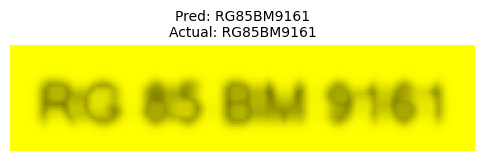

Predicted: RG85BM9161
Actual:    RG85BM9161
----------------------------------------


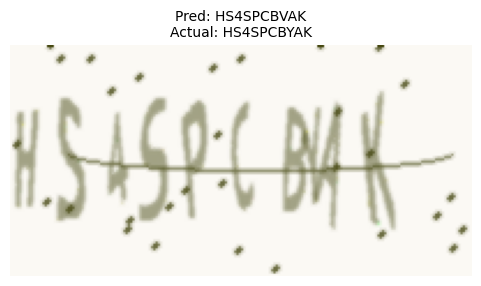

Predicted: HS4SPCBVAK
Actual:    HS4SPCBYAK
----------------------------------------


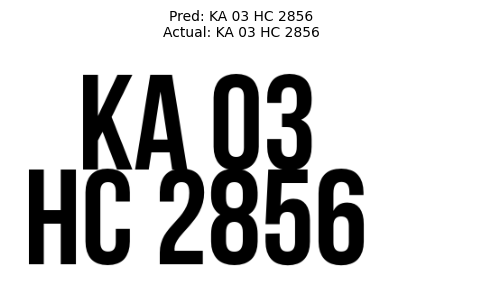

Predicted: KA 03 HC 2856
Actual:    KA 03 HC 2856
----------------------------------------


In [29]:
# Optional: Test the model on a few evaluation samples
import random
import matplotlib.pyplot as plt

# Get a few samples from eval dataset
test_indices = random.sample(range(len(eval_ds)), min(3, len(eval_ds)))

print("Testing model on sample images:\n")

for idx in test_indices:
    sample = eval_ds[idx]
    image_path = eval_dataset[idx]['image_path']
    
    # Load and display image
    image = Image.open(image_path).convert("RGB")
    
    # Prepare input
    pixel_values = sample['pixel_values'].unsqueeze(0).to(device)
    
    # Generate prediction
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    
    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    actual_text = eval_dataset[idx]['text']
    
    # Display
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f"Pred: {predicted_text}\nActual: {actual_text}", fontsize=10)
    plt.show()
    
    print(f"Predicted: {predicted_text}")
    print(f"Actual:    {actual_text}")
    print("-" * 40)